# Finite spin-$\tfrac12$ rings with Heisenberg and Dzyaloshinsky--Moriya interaction

This notebook computes the numerical quantities used in the paper:

1. the relaxed average nearest-neighbor connected correlation $C_{\mathrm{NN}}(\beta)$;
2. the relaxed average local magnetization $M_\beta$;
3. the single-site von Neumann entropy $S_{\rm VN}^{(n)}$;
4. the finite-size saturation field $B_c(N,D)$ and its $\beta$-dependent version.

The convention used here is the same as in the manuscript:

\begin{equation}
\hat H_\beta(\psi)
=
\beta \hat H_{QM}
+
(1-\beta)\hat H_{\rm MF}(\psi)
+
\hat H_B .
\end{equation}

Thus $\beta=0$ is the mean-field limit and $\beta=1$ is the fully quantum limit.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output directory for figures and data files.
OUTPUT_DIR = Path("paper_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Reproducibility.
SEED = 12345                         # Random seed used for reproducible initial states.
rng = np.random.default_rng(SEED)    # NumPy random-number generator.

# Physical parameters.
J = 1.0                              # Heisenberg exchange coupling; sets the energy scale.
D = 0.2                              # Dzyaloshinsky--Moriya coupling; here D/J = 0.2.
B = 0.0                              # External magnetic field along the z-axis.

# Dissipative dynamics.
alpha = 0.15                         # Damping strength in the Gisin--Schrodinger equation.
dt = 0.03                            # Time step used in the RK4 time integration.
n_steps = 3000                       # Number of RK4 time steps for each trajectory.
n_starts = 4                         # Number of random product initial states per beta value.

# These are the values used for the paper figures.
N_list = [3, 4, 5, 6, 7, 8]
betas = np.linspace(0.0, 1.0, 21)

print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"N_list = {N_list}")
print(f"number of beta values = {len(betas)}")

Output directory: /Users/raul/Google Drive/Collaborators/Robert/new_paper/paper_outputs
N_list = [3, 4, 5, 6, 7, 8]
number of beta values = 21


## Spin operators and Hamiltonians

We work in the computational basis of $(\mathbb C^2)^{\otimes N}$, with

\begin{equation}
S^a_n = \frac12 I\otimes\cdots\otimes \sigma_a\otimes\cdots\otimes I.
\end{equation}

The quantum Hamiltonian is

\begin{equation}
\hat H_{QM}
=
J\sum_{(n,m)} \vec S_n\cdot\vec S_m
+
D\sum_{(n,m)}(\vec S_n\times\vec S_m)_z.
\end{equation}

The mean-field Hamiltonian is the state-dependent operator

\begin{equation}
\hat H_{\rm MF}(\psi)
=
\frac{J}{2}\sum_{(n,m)}
\bigl(\vec S_n\cdot\langle\vec S_m\rangle
+\vec S_m\cdot\langle\vec S_n\rangle\bigr)
+
\frac{D}{2}\sum_{(n,m)}
\bigl[(\vec S_n\times\langle\vec S_m\rangle)_z
-(\vec S_m\times\langle\vec S_n\rangle)_z\bigr].
\end{equation}

In [2]:
# Pauli matrices and single-site spin matrices.
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
paulis = [sigma_x, sigma_y, sigma_z]


def kron_all(mats):
    """Kronecker product of a list of matrices."""
    out = mats[0]
    for M in mats[1:]:
        out = np.kron(out, M)
    return out


def spin_operator(N, site, component):
    """Return S_site^component for a spin-1/2 ring with N sites."""
    mats = [I2] * N
    mats[site] = 0.5 * paulis[component]
    return kron_all(mats)


class SpinRingModel:
    """Dense-matrix implementation of the finite spin ring model."""

    def __init__(self, N, J=1.0, D=0.2, B=0.0):
        self.N = int(N)
        self.J = float(J)
        self.D = float(D)
        self.B = float(B)
        self.dim = 2 ** self.N
        self.neighbors = [(n, (n + 1) % self.N) for n in range(self.N)]
        self.eye = np.eye(self.dim, dtype=complex)

        self.S = [
            [spin_operator(self.N, n, a) for a in range(3)]
            for n in range(self.N)
        ]

        self.bond_dot_ops = []
        self.bond_cross_z_ops = []
        for n, m in self.neighbors:
            dot = sum(self.S[n][a] @ self.S[m][a] for a in range(3))
            cross_z = self.S[n][0] @ self.S[m][1] - self.S[n][1] @ self.S[m][0]
            self.bond_dot_ops.append(dot)
            self.bond_cross_z_ops.append(cross_z)

        self.H_J = self.J * sum(self.bond_dot_ops)
        self.H_DM = self.D * sum(self.bond_cross_z_ops)
        self.H_QM = self.H_J + self.H_DM
        self.H_B = -self.B * sum(self.S[n][2] for n in range(self.N))

    def local_expectations(self, psi):
        """Return array with entries <S_n^a>, shape (N,3)."""
        psi = normalize(psi)
        vals = np.zeros((self.N, 3), dtype=float)
        for n in range(self.N):
            for a in range(3):
                vals[n, a] = np.vdot(psi, self.S[n][a] @ psi).real
        return vals

    def mean_field_hamiltonian(self, psi):
        """Return H_MF(psi), without the factor (1-beta)."""
        exp = self.local_expectations(psi)
        H = np.zeros((self.dim, self.dim), dtype=complex)

        for n, m in self.neighbors:
            # Heisenberg mean-field contribution.
            for a in range(3):
                H += 0.5 * self.J * (self.S[n][a] * exp[m, a] + self.S[m][a] * exp[n, a])

            # Dzyaloshinsky--Moriya mean-field contribution, D along z.
            H += 0.5 * self.D * (
                self.S[n][0] * exp[m, 1]
                - self.S[n][1] * exp[m, 0]
                - self.S[m][0] * exp[n, 1]
                + self.S[m][1] * exp[n, 0]
            )

        # Symmetrize to remove roundoff-level anti-Hermitian noise.
        return 0.5 * (H + H.conj().T)

    def full_hamiltonian(self, psi, beta):
        """Return H_beta(psi) = beta H_QM + (1-beta) H_MF(psi) + H_B."""
        return beta * self.H_QM + (1.0 - beta) * self.mean_field_hamiltonian(psi) + self.H_B

    def operator_energy(self, psi, beta):
        """Return <psi|H_beta(psi)|psi>, the operator expectation used in the Gisin term."""
        psi = normalize(psi)
        H = self.full_hamiltonian(psi, beta)
        return np.vdot(psi, H @ psi).real

    def mean_field_energy_expectation(self, psi):
        """Return <H_MF(psi)> = sum_bonds [J <S_n>.<S_m> + D (<S_n>x<S_m>)_z]."""
        exp = self.local_expectations(psi)
        E = 0.0
        for n, m in self.neighbors:
            E += self.J * float(np.dot(exp[n], exp[m]))
            E += self.D * float(exp[n, 0] * exp[m, 1] - exp[n, 1] * exp[m, 0])
        return E

    def energy_functional(self, psi, beta):
        """
        Energy functional whose variational derivative gives H_beta.

        For the state-dependent mean-field part, the functional contains
        one half of <H_MF(psi)>.
        """
        psi = normalize(psi)
        E_qm = np.vdot(psi, self.H_QM @ psi).real
        E_b = np.vdot(psi, self.H_B @ psi).real
        E_mf = self.mean_field_energy_expectation(psi)
        return beta * E_qm + 0.5 * (1.0 - beta) * E_mf + E_b

## Initial states and Gisin--Schrödinger relaxation

The evolution equation used in the simulations is

\begin{equation}
\frac{d}{dt}|\psi\rangle
=
-i\hat H_\beta(\psi)|\psi\rangle
-
\alpha\bigl(\hat H_\beta(\psi)-\langle \hat H_\beta(\psi)\rangle\bigr)|\psi\rangle.
\end{equation}

For the paper figures, the default initial states are random product states. This is important for the mean-field endpoint: in the limit $\beta=0$, a product initial state remains in the product-state manifold.

The Hamiltonian is recomputed at every Runge--Kutta substage, and the state is normalized before evaluating expectation values.

In [3]:
def normalize(psi):
    norm = np.linalg.norm(psi)
    if norm == 0:
        raise ValueError("Cannot normalize the zero vector.")
    return psi / norm


def random_product_state(N, rng):
    """Random product state, with each single-spin state uniformly distributed on the Bloch sphere."""
    factors = []
    for _ in range(N):
        u = rng.uniform(-1.0, 1.0)
        phi = rng.uniform(0.0, 2.0 * np.pi)
        theta = np.arccos(u)
        single = np.array([
            np.cos(theta / 2.0),
            np.exp(1j * phi) * np.sin(theta / 2.0),
        ], dtype=complex)
        factors.append(single)
    psi = factors[0]
    for f in factors[1:]:
        psi = np.kron(psi, f)
    return normalize(psi)


def random_full_state(dim, rng):
    """Random normalized vector in the full Hilbert space."""
    psi = rng.normal(size=dim) + 1j * rng.normal(size=dim)
    return normalize(psi)


def gisin_rhs(model, psi, beta, alpha):
    """Right-hand side of the nonlinear Gisin--Schroedinger equation."""
    psi = normalize(psi)
    H = model.full_hamiltonian(psi, beta)
    E = np.vdot(psi, H @ psi).real
    Hpsi = H @ psi
    return -1j * Hpsi - alpha * (Hpsi - E * psi)


def rk4_step(model, psi, beta, alpha, dt):
    """One normalized RK4 step for the state-dependent flow."""
    psi = normalize(psi)
    k1 = gisin_rhs(model, psi, beta, alpha)
    k2 = gisin_rhs(model, psi + 0.5 * dt * k1, beta, alpha)
    k3 = gisin_rhs(model, psi + 0.5 * dt * k2, beta, alpha)
    k4 = gisin_rhs(model, psi + dt * k3, beta, alpha)
    return normalize(psi + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4))


def evolve(model, psi0, beta, alpha=0.15, dt=0.03, n_steps=3000, store_every=None):
    """Evolve one initial state. Optionally store diagnostics every store_every steps."""
    psi = normalize(psi0)
    records = []

    for step in range(n_steps):
        if store_every is not None and (step % store_every == 0 or step == n_steps - 1):
            records.append({
                "step": step,
                "time": step * dt,
                "operator_energy": model.operator_energy(psi, beta),
                "energy_functional": model.energy_functional(psi, beta),
                "M_beta": average_local_magnetization(model, psi),
                "C_NN": average_connected_nn_correlation(model, psi),
                "S_VN_avg": average_single_site_entropy(model, psi),
            })
        psi = rk4_step(model, psi, beta, alpha, dt)

    if store_every is not None:
        records.append({
            "step": n_steps,
            "time": n_steps * dt,
            "operator_energy": model.operator_energy(psi, beta),
            "energy_functional": model.energy_functional(psi, beta),
            "M_beta": average_local_magnetization(model, psi),
            "C_NN": average_connected_nn_correlation(model, psi),
            "S_VN_avg": average_single_site_entropy(model, psi),
        })
        return psi, pd.DataFrame(records)

    return psi

## Observables

The three main observables used in the paper are:

\begin{equation}
C_{\rm NN}
=
\frac1N\sum_{(n,m)}
\left(
\langle \vec S_n\cdot\vec S_m\rangle
-
\langle \vec S_n\rangle\cdot\langle \vec S_m\rangle
\right),
\end{equation}

\begin{equation}
M_\beta
=
\frac1N\sum_{n=1}^N |\langle\vec S_n\rangle|,
\end{equation}

and the single-site von Neumann entropy. For a spin-$\tfrac12$ site,

\begin{equation}
\lambda_\pm^{(n)}=\frac12\pm |\langle\vec S_n\rangle|,
\qquad
S_{\rm VN}^{(n)}
=-\lambda_+^{(n)}\log_2\lambda_+^{(n)}
-\lambda_-^{(n)}\log_2\lambda_-^{(n)}.
\end{equation}

In [4]:
def average_local_magnetization(model, psi):
    exp = model.local_expectations(psi)
    return float(np.mean(np.linalg.norm(exp, axis=1)))


def average_connected_nn_correlation(model, psi):
    psi = normalize(psi)
    exp = model.local_expectations(psi)
    vals = []
    for op, (n, m) in zip(model.bond_dot_ops, model.neighbors):
        two_point = np.vdot(psi, op @ psi).real
        disconnected = float(np.dot(exp[n], exp[m]))
        vals.append(two_point - disconnected)
    return float(np.mean(vals))


def average_dm_connected_correlation_z(model, psi):
    """Average z-component of the connected DM correlation."""
    psi = normalize(psi)
    exp = model.local_expectations(psi)
    vals = []
    for op, (n, m) in zip(model.bond_cross_z_ops, model.neighbors):
        two_point = np.vdot(psi, op @ psi).real
        disconnected = float(exp[n, 0] * exp[m, 1] - exp[n, 1] * exp[m, 0])
        vals.append(two_point - disconnected)
    return float(np.mean(vals))


def single_site_entropy_from_magnetization(mag):
    """Von Neumann entropy in bits for one spin with |<S>| = mag."""
    lam_plus = 0.5 + mag
    lam_minus = 0.5 - mag
    vals = np.array([lam_plus, lam_minus], dtype=float)
    vals = np.clip(vals, 0.0, 1.0)
    nz = vals > 1e-15
    return float(-np.sum(vals[nz] * np.log2(vals[nz])))


def single_site_entropy(model, psi, site=0):
    exp = model.local_expectations(psi)
    mag = float(np.linalg.norm(exp[site]))
    return single_site_entropy_from_magnetization(mag)


def average_single_site_entropy(model, psi):
    exp = model.local_expectations(psi)
    mags = np.linalg.norm(exp, axis=1)
    return float(np.mean([single_site_entropy_from_magnetization(m) for m in mags]))


def observables_row(model, psi, beta, start_id=None):
    return {
        "N": model.N,
        "beta": float(beta),
        "start_id": start_id,
        "operator_energy": model.operator_energy(psi, beta),
        "energy_functional": model.energy_functional(psi, beta),
        "C_NN": average_connected_nn_correlation(model, psi),
        "C_DM_z": average_dm_connected_correlation_z(model, psi),
        "M_beta": average_local_magnetization(model, psi),
        "S_VN_site1": single_site_entropy(model, psi, site=0),
        "S_VN_avg": average_single_site_entropy(model, psi),
    }

## Multi-start relaxation

For each value of $\beta$ we evolve several random product-state initial conditions and retain the relaxed state with the lowest value of the energy functional

\begin{equation}
\mathcal E_\beta(\psi)
=
\beta\langle H_{QM}\rangle
+
\frac{1-\beta}{2}\langle H_{\rm MF}(\psi)\rangle
+
\langle H_B\rangle.
\end{equation}

The factor $1/2$ in the mean-field contribution avoids double-counting in the nonlinear variational energy.

In [5]:
def relax_for_beta(
    model,
    beta,
    n_starts=4,
    alpha=0.15,
    dt=0.03,
    n_steps=3000,
    seed=0,
    initial_state_type="product",
):
    """Run several random starts and keep the lowest-energy relaxed state."""
    local_rng = np.random.default_rng(seed)
    rows = []
    best = None

    for start_id in range(n_starts):
        if initial_state_type == "product":
            psi0 = random_product_state(model.N, local_rng)
        elif initial_state_type == "full":
            psi0 = random_full_state(model.dim, local_rng)
        else:
            raise ValueError("initial_state_type must be 'product' or 'full'")

        psi = evolve(model, psi0, beta, alpha=alpha, dt=dt, n_steps=n_steps)
        row = observables_row(model, psi, beta, start_id=start_id)
        rows.append(row)

        if best is None or row["energy_functional"] < best[0]:
            best = (row["energy_functional"], psi, row)

    return best[1], best[2], pd.DataFrame(rows)


def run_beta_sweep(
    N,
    betas,
    J=1.0,
    D=0.2,
    B=0.0,
    alpha=0.15,
    dt=0.03,
    n_steps=3000,
    n_starts=4,
    seed=12345,
    initial_state_type="product",
):
    model = SpinRingModel(N=N, J=J, D=D, B=B)
    best_rows = []
    all_rows = []

    for j, beta in enumerate(betas):
        print(f"N={N}, beta={beta:.3f} ({j+1}/{len(betas)})")
        psi_best, row_best, df_all = relax_for_beta(
            model,
            beta,
            n_starts=n_starts,
            alpha=alpha,
            dt=dt,
            n_steps=n_steps,
            seed=seed + 1000 * N + j,
            initial_state_type=initial_state_type,
        )
        best_rows.append(row_best)
        all_rows.append(df_all)

    return pd.DataFrame(best_rows), pd.concat(all_rows, ignore_index=True)

## Figure 1: connected nearest-neighbor correlation versus $\beta$

This cell computes the relaxed connected nearest-neighbor correlation $C_{\rm NN}$ for $N=3,4,5,6,7,8$ and saves the figure as

`correlations_vs_beta_N345678.png`.

N=3, beta=0.000 (1/21)
N=3, beta=0.050 (2/21)
N=3, beta=0.100 (3/21)
N=3, beta=0.150 (4/21)
N=3, beta=0.200 (5/21)
N=3, beta=0.250 (6/21)
N=3, beta=0.300 (7/21)
N=3, beta=0.350 (8/21)
N=3, beta=0.400 (9/21)
N=3, beta=0.450 (10/21)
N=3, beta=0.500 (11/21)
N=3, beta=0.550 (12/21)
N=3, beta=0.600 (13/21)
N=3, beta=0.650 (14/21)
N=3, beta=0.700 (15/21)
N=3, beta=0.750 (16/21)
N=3, beta=0.800 (17/21)
N=3, beta=0.850 (18/21)
N=3, beta=0.900 (19/21)
N=3, beta=0.950 (20/21)
N=3, beta=1.000 (21/21)
N=4, beta=0.000 (1/21)
N=4, beta=0.050 (2/21)
N=4, beta=0.100 (3/21)
N=4, beta=0.150 (4/21)
N=4, beta=0.200 (5/21)
N=4, beta=0.250 (6/21)
N=4, beta=0.300 (7/21)
N=4, beta=0.350 (8/21)
N=4, beta=0.400 (9/21)
N=4, beta=0.450 (10/21)
N=4, beta=0.500 (11/21)
N=4, beta=0.550 (12/21)
N=4, beta=0.600 (13/21)
N=4, beta=0.650 (14/21)
N=4, beta=0.700 (15/21)
N=4, beta=0.750 (16/21)
N=4, beta=0.800 (17/21)
N=4, beta=0.850 (18/21)
N=4, beta=0.900 (19/21)
N=4, beta=0.950 (20/21)
N=4, beta=1.000 (21/21)
N=5, beta=

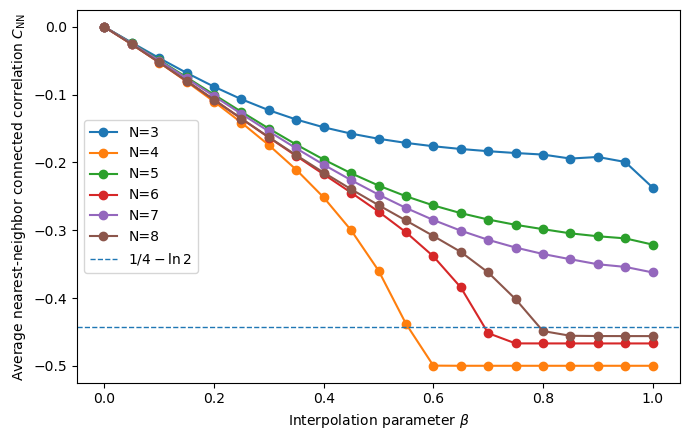

In [6]:
correlation_results = []
all_start_results = []

for N in N_list:
    df_best, df_all = run_beta_sweep(
        N=N,
        betas=betas,
        J=J,
        D=D,
        B=B,
        alpha=alpha,
        dt=dt,
        n_steps=n_steps,
        n_starts=n_starts,
        seed=SEED,
        initial_state_type="product",
    )
    correlation_results.append(df_best)
    all_start_results.append(df_all)

results = pd.concat(correlation_results, ignore_index=True)
all_starts = pd.concat(all_start_results, ignore_index=True)

results.to_csv(OUTPUT_DIR / "beta_sweep_best_results.csv", index=False)
all_starts.to_csv(OUTPUT_DIR / "beta_sweep_all_starts.csv", index=False)

plt.figure(figsize=(7, 4.5))
for N, df in results.groupby("N"):
    plt.plot(df["beta"], df["C_NN"], marker="o", label=f"N={N}")
plt.axhline(0.25 - np.log(2.0), linestyle="--", linewidth=1, label=r"$1/4-\ln 2$")
plt.xlabel(r"Interpolation parameter $\beta$")
plt.ylabel(r"Average nearest-neighbor connected correlation $C_{\rm NN}$")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlations_vs_beta_N345678.png", dpi=300)
plt.show()

## Figure 2: average local magnetization versus $\beta$

This cell uses the same relaxed states and plots

\begin{equation}
M_\beta=\frac1N\sum_{n=1}^N |\langle\vec S_n\rangle|.
\end{equation}


The figure is saved as `magnetization_vs_beta_N345678.png`.

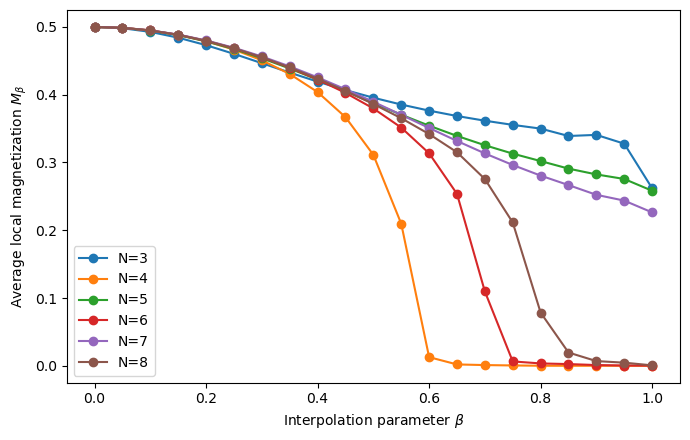

In [7]:
plt.figure(figsize=(7, 4.5))
for N, df in results.groupby("N"):
    plt.plot(df["beta"], df["M_beta"], marker="o", label=f"N={N}")
plt.xlabel(r"Interpolation parameter $\beta$")
plt.ylabel(r"Average local magnetization $M_\beta$")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "magnetization_vs_beta_N345678.png", dpi=300)
plt.show()

## Figure 3: single-site entropy versus $\beta$

The entropy is computed from the local magnetization using

\begin{equation}
\lambda_\pm^{(n)}=\frac12\pm |\langle\vec S_n\rangle|,
\qquad
S_{\rm VN}^{(n)}
=-\lambda_+^{(n)}\log_2\lambda_+^{(n)}
-\lambda_-^{(n)}\log_2\lambda_-^{(n)}.
\end{equation}

The cell below plots the site-averaged single-site entropy

\begin{equation}
\overline S_{\rm VN}=\frac1N\sum_n S_{\rm VN}^{(n)}.
\end{equation}

By default it uses the already computed data for all $N=3,4,5,6,7,8$. If one only wants to display one ring, set `entropy_N = 3` and plot only that curve.

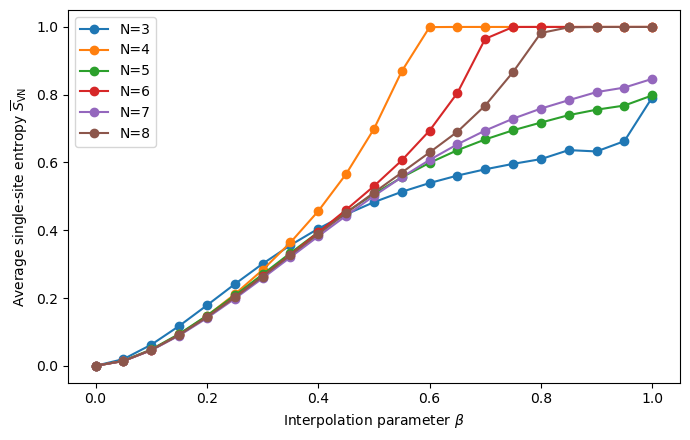

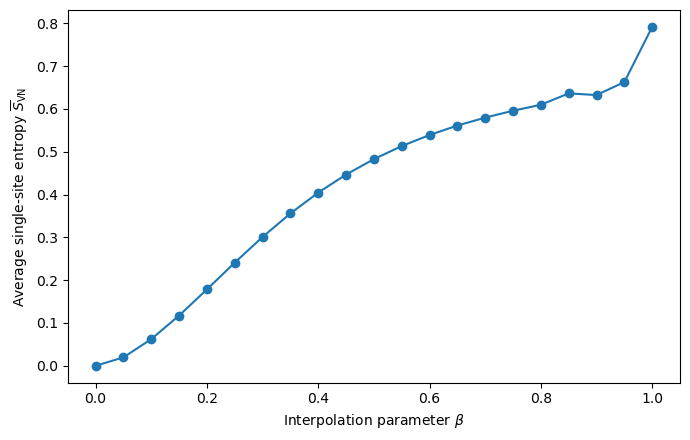

In [12]:
plt.figure(figsize=(7, 4.5))
for N, df in results.groupby("N"):
    plt.plot(df["beta"], df["S_VN_avg"], marker="o", label=f"N={N}")
plt.xlabel(r"Interpolation parameter $\beta$")
plt.ylabel(r"Average single-site entropy $\overline{S}_{\rm VN}$")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "entropy_vs_beta_N345678.png", dpi=300)
plt.show()

# Optional: for a single-N version.
entropy_N = 3
df_entropy = results[results["N"] == entropy_N].copy()
plt.figure(figsize=(7, 4.5))
plt.plot(df_entropy["beta"], df_entropy["S_VN_avg"], marker="o")
plt.xlabel(r"Interpolation parameter $\beta$")
plt.ylabel(r"Average single-site entropy $\overline{S}_{\rm VN}$")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"entropy_vs_beta_N{entropy_N}.png", dpi=300)
plt.show()

## Optional diagnostic: time series for one representative run

This cell stores the time evolution of energy, magnetization, correlation, and entropy for one chosen value of $N$ and $\beta$. This is useful for checking that the relaxation has reached a stationary regime.

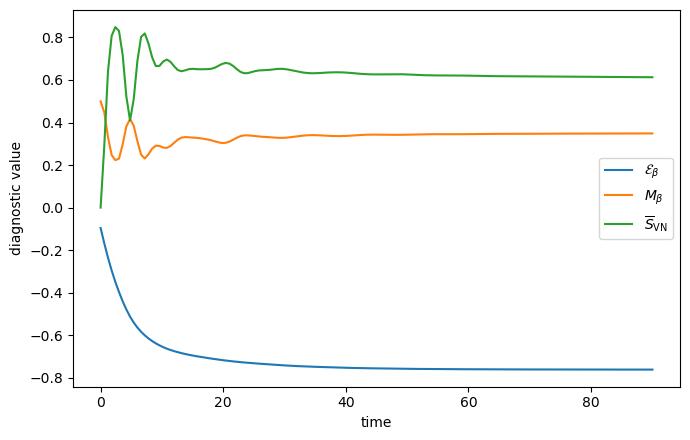

In [8]:
plt.close("all")

N_ts = 3
beta_ts = 0.8
model_ts = SpinRingModel(N=N_ts, J=J, D=D, B=B)

psi0_ts = random_product_state(N_ts, rng)

psi_final_ts, df_ts = evolve(
    model_ts,
    psi0_ts,
    beta_ts,
    alpha=alpha,
    dt=dt,
    n_steps=n_steps,
    store_every=20,
)

df_ts.to_csv(
    OUTPUT_DIR / f"timeseries_N{N_ts}_beta{beta_ts:.2f}.csv",
    index=False,
)

plt.figure(figsize=(7, 4.5))

plt.plot(
    df_ts["time"],
    df_ts["energy_functional"],
    label=r"$\mathcal{E}_{\beta}$",
)

plt.plot(
    df_ts["time"],
    df_ts["M_beta"],
    label=r"$M_{\beta}$",
)

plt.plot(
    df_ts["time"],
    df_ts["S_VN_avg"],
    label=r"$\overline{S}_{\rm VN}$",
)

plt.xlabel("time")
plt.ylabel("diagnostic value")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / f"timeseries_energy_mz_entropy_N{N_ts}_beta{beta_ts:.2f}.png",
    dpi=300,
)

plt.show()

## Saturation field formulas

For the fully quantum case $\beta=1$, the one-magnon formula used in the paper is

\begin{equation}
B_c(N,D)
=
\max_{k\in \frac{2\pi}{N}\mathbb Z}
\left[J(1-\cos k)-D\sin k\right].
\end{equation}

For the interpolating Hamiltonian, linearization around the fully polarized fixed point gives

\begin{equation}
B_c(\beta;N,D)=\frac{1+\beta}{2}B_c(N,D).
\end{equation}

The thermodynamic limit is

\begin{equation}
B_c(\beta,D)=\frac{1+\beta}{2}\left(J+\sqrt{J^2+D^2}\right).
\end{equation}

In [9]:
def Bc_quantum_formula(N, J=1.0, D=0.2):
    ks = 2.0 * np.pi * np.arange(N) / N
    vals = J * (1.0 - np.cos(ks)) - D * np.sin(ks)
    idx = int(np.argmax(vals))
    return float(vals[idx]), float(ks[idx])


def Bc_beta_formula(beta, N, J=1.0, D=0.2):
    Bc, k_star = Bc_quantum_formula(N, J=J, D=D)
    return 0.5 * (1.0 + beta) * Bc, k_star


def Bc_thermodynamic(beta, J=1.0, D=0.2):
    return 0.5 * (1.0 + beta) * (J + np.sqrt(J**2 + D**2))

# Table for the finite-size quantum saturation field.
rows = []
for N in range(3, 21):
    Bc, k_star = Bc_quantum_formula(N, J=J, D=D)
    rows.append({"N": N, "B_c(N,D)": Bc, "k_star": k_star})
Bc_table = pd.DataFrame(rows)
Bc_table.to_csv(OUTPUT_DIR / "critical_field_quantum_table.csv", index=False)
Bc_table

,N,"B_c(N,D)",k_star
0,3,1.673205,4.188790
1,4,2.000000,3.141593
2,5,1.926574,3.769911
3,6,2.000000,3.141593
4,7,1.987746,3.590392
5,8,2.000000,3.141593
6,9,2.008097,3.490659
7,10,2.000000,3.141593
8,11,2.015839,3.427192
9,12,2.000000,3.141593


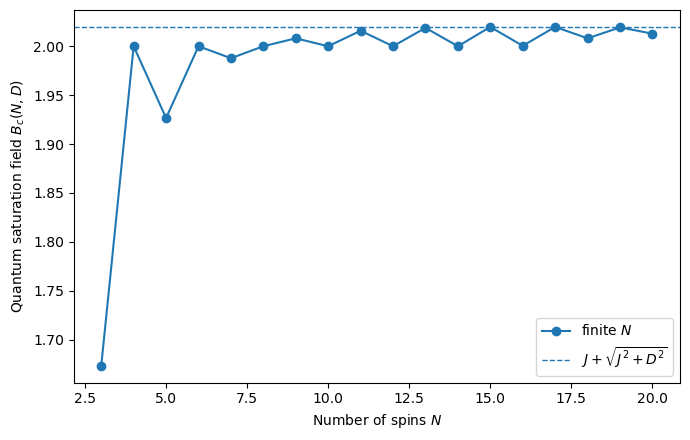

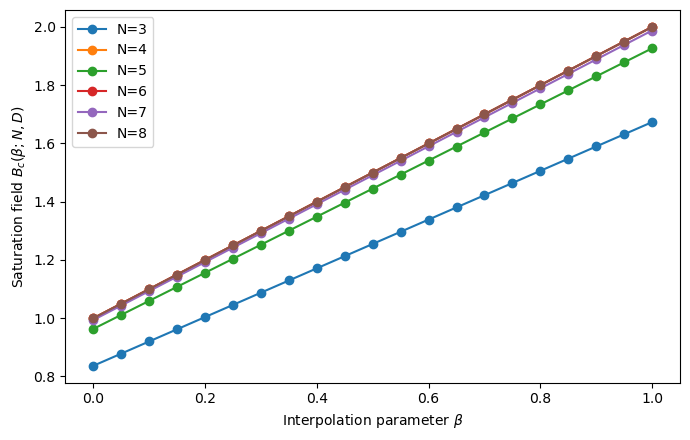

In [10]:
plt.figure(figsize=(7, 4.5))
plt.plot(Bc_table["N"], Bc_table["B_c(N,D)"], marker="o", label=r"finite $N$")
plt.axhline(J + np.sqrt(J**2 + D**2), linestyle="--", linewidth=1, label=r"$J+\sqrt{J^2+D^2}$")
plt.xlabel(r"Number of spins $N$")
plt.ylabel(r"Quantum saturation field $B_c(N,D)$")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "critical_field_quantum_vs_N.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 4.5))
for N in [3, 4, 5, 6, 7, 8]:
    vals = [Bc_beta_formula(beta, N, J=J, D=D)[0] for beta in betas]
    plt.plot(betas, vals, marker="o", label=f"N={N}")
plt.xlabel(r"Interpolation parameter $\beta$")
plt.ylabel(r"Saturation field $B_c(\beta;N,D)$")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "critical_field_beta_vs_beta_N345678.png", dpi=300)
plt.show()

## Exact diagonalization check of the one-magnon formula

This final check restricts $\hat H_{QM}$ to the fully polarized sector and to the one-magnon sector. It verifies numerically that

\begin{equation}
B_c(N,D)=E_0(N/2)-E_0(N/2-1)
\end{equation}

agrees with the finite-momentum formula above.

In [11]:
def one_down_index(N, site):
    """Computational basis index for the state with one down spin at `site` and all others up."""
    # With the Kronecker ordering used here, site 0 is the most significant bit.
    return 1 << (N - 1 - site)


def Bc_exact_diagonalization_one_magnon(N, J=1.0, D=0.2):
    model = SpinRingModel(N=N, J=J, D=D, B=0.0)
    H = model.H_QM
    idx_F = 0
    one_magnon_indices = [one_down_index(N, site) for site in range(N)]
    H1 = H[np.ix_(one_magnon_indices, one_magnon_indices)]
    E_F = H[idx_F, idx_F].real
    E_1_min = np.linalg.eigvalsh(H1)[0].real
    return float(E_F - E_1_min)

rows = []
for N in range(3, 9):
    Bc_formula, _ = Bc_quantum_formula(N, J=J, D=D)
    Bc_exact = Bc_exact_diagonalization_one_magnon(N, J=J, D=D)
    rows.append({
        "N": N,
        "B_c_formula": Bc_formula,
        "B_c_exact_one_magnon": Bc_exact,
        "absolute_error": abs(Bc_formula - Bc_exact),
    })
check_table = pd.DataFrame(rows)
check_table.to_csv(OUTPUT_DIR / "critical_field_exact_check.csv", index=False)
check_table

,N,B_c_formula,B_c_exact_one_magnon,absolute_error
0,3,1.673205,1.673205,4.440892e-16
1,4,2.000000,2.000000,0.000000e+00
2,5,1.926574,1.926574,2.220446e-16
3,6,2.000000,2.000000,0.000000e+00
4,7,1.987746,1.987746,6.661338e-16
5,8,2.000000,2.000000,0.000000e+00


## Files produced by this notebook

The main output files are saved in `paper_outputs/`:

- `correlations_vs_beta_N345678.png`
- `magnetization_vs_beta_N345678.png`
- `entropy_vs_beta_N345678.png`
- `entropy_vs_beta_N3.png`
- `critical_field_quantum_vs_N.png`
- `critical_field_beta_vs_beta_N345678.png`
- `beta_sweep_best_results.csv`
- `beta_sweep_all_starts.csv`
- `critical_field_quantum_table.csv`
- `critical_field_exact_check.csv`

For the paper, we used the PNG files and kept the CSV files as reproducibility data.